revisr top grd

## precarga en terminal

nota
```
python -m venv .venv
.venv\Scripts\Activate
pip install pandas matplotlib seaborn scikit-learn numpy tensorflow keras keras-tuner imblearn catboost shap
```

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import keras_tuner as kt
import matplotlib.pyplot as plt

## Carga dataset

In [2]:
corpus = []
target = []
edad = []
sexo = []
severidad = []
archivo = open("dataset_elpino.csv", encoding="utf-8")
header = archivo.readline().strip().split(";")
features = []
for col in header:
    col = col.split("-")[0].strip()
    if col.startswith("Diag") or col.startswith("Proc"):
        col = col.split(" ")[0] + col.split(" ")[1]
    features.append(col)
for linea in archivo:
    row = []
    linea = linea.strip().split(";")
    for i in range(len(linea)):
        col = linea[i].split("-")[0].strip()
        if i == 67:
            target.append(col)
        elif i == 66:
            sexo.append(1 if col == "Mujer" else 0)
        elif i == 65:
            edad.append(int(col))
        else:
            row.append(col)
    corpus.append(row)

In [3]:
corpus[0]

['A41.8',
 'B37.6',
 'I39.8',
 'N10',
 'B96.1',
 'L89.9',
 'L08.9',
 'B96.2',
 'A41.5',
 'J86.9',
 'U07.1',
 'Y95',
 'N18.5',
 'E87.1',
 'D64.9',
 'G82.2',
 'N31.9',
 'I10',
 'K70.4',
 'F19.2',
 'F10.2',
 'E46',
 'G40.9',
 'L21.9',
 'Z93.5',
 'Z93.3',
 'Z99.2',
 'Z91.6',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '86.28',
 '34.91',
 '88.38',
 '87.41',
 '88.75',
 '88.01',
 '88.43',
 '88.41',
 '87.44',
 '99.29',
 '99.19',
 '99.18',
 '99.21',
 '99.26',
 '99.23',
 '93.94',
 '89.52',
 '90.59',
 '89.65',
 '39.95',
 '39.95',
 '99.04',
 '90.39',
 '99.84',
 '88.72',
 '90.42',
 '90.52',
 '91.39',
 '91.33',
 '87.03']

In [4]:
df = pd.DataFrame(corpus, columns=features[:-3])
df["Edad"] = edad
df["Sexo"] = sexo
df["GRD"] = target
df.replace('', np.nan, inplace=True)

In [5]:
df.head()

,Diag01,Diag02,Diag03,Diag04,Diag05,Diag06,Diag07,Diag08,Diag09,Diag10,...,Proced24,Proced25,Proced26,Proced27,Proced28,Proced29,Proced30,Edad,Sexo,GRD
0,A41.8,B37.6,I39.8,N10,B96.1,L89.9,L08.9,B96.2,A41.5,J86.9,...,99.84,88.72,90.42,90.52,91.39,91.33,87.03,40,0,184103
1,U07.1,J12.8,R06.0,R05,R50.9,Z29.0,Z01.7,J96.00,J94.2,J92.9,...,91.62,90.43,91.39,90.52,91.32,96.59,90.99,53,0,041013
2,K56.5,R57.2,R57.1,J80,Y95,J15.0,U82.2,B95.6,B96.8,B37.1,...,99.84,91.73,90.53,99.26,89.39,89.66,89.65,65,0,041013
3,K76.8,K66.1,N18.5,D64.9,E87.5,E87.2,J81,N17.8,J44.9,R41.0,...,57.94,00.13,00.17,99.04,99.18,99.21,99.23,61,0,041023
4,T81.0,Y83.2,S31.1,S36.80,W31.62,J96.09,J15.0,U82.2,U07.1,N39.0,...,90.52,91.39,91.32,93.90,99.15,96.59,45.13,30,0,041023


## 2. Análisis de datos faltantes y tipos

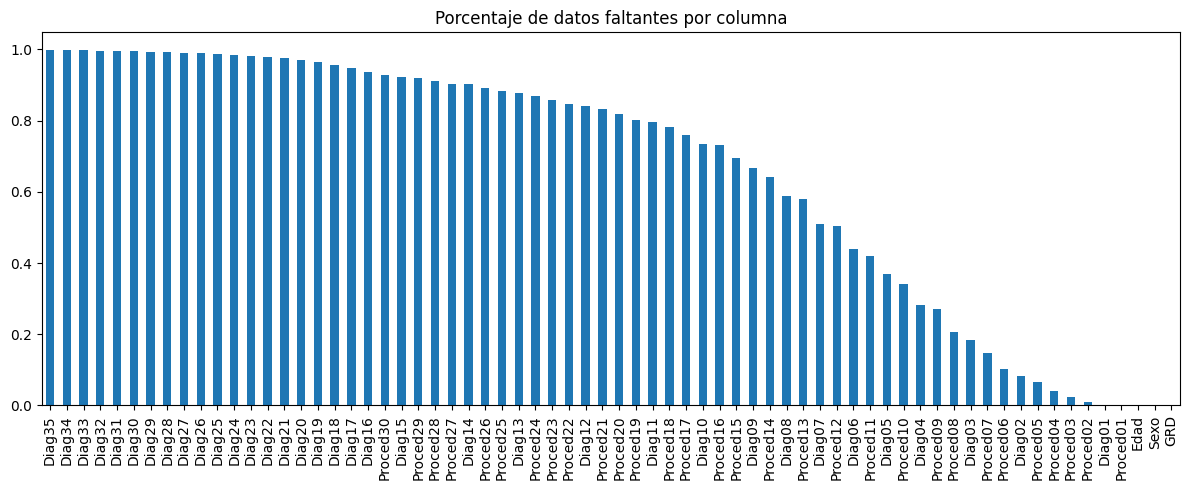

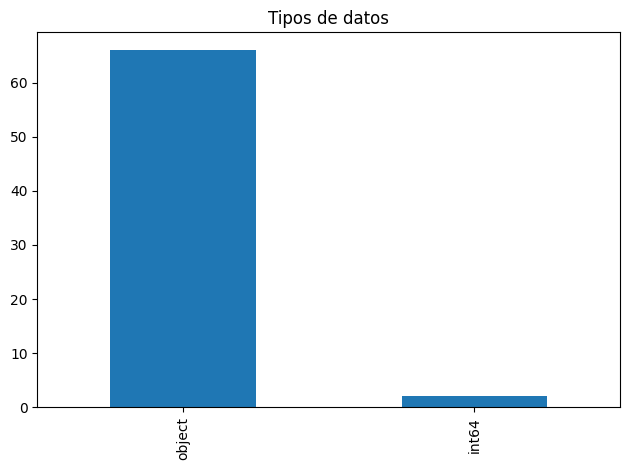

In [6]:
# Grafico 1
plt.figure(figsize=(12, 5))
df.isnull().mean().sort_values(ascending=False).plot(kind='bar', title='Porcentaje de datos faltantes por columna')
plt.tight_layout()
plt.show()
# Grafico 2
df.dtypes.value_counts().plot(kind='bar', title='Tipos de datos')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento de datos

In [7]:
df = df.loc[:, df.isnull().mean() < 0.5]
df = df[df["Edad"] <= 100]
df["Edad"] = pd.cut(df["Edad"], bins=[0, 18, 60, 100], labels=["Niño", "Adulto", "Anciano"])
df = df[df["GRD"].notnull()]

## Selecciono los 10 GRD mas comunes para la prediccion

In [8]:
top_10_grds = df["GRD"].value_counts().nlargest(10).index.tolist()
df_top = df[df["GRD"].isin(top_10_grds)].copy()
print(df["GRD"].value_counts().nlargest(10))

GRD
146101    813
146121    639
146131    538
158171    389
134161    325
071141    317
044153    287
061131    252
041023    248
146102    244
Name: count, dtype: int64


In [9]:
# Guardar df filtrado (opcional)
df_top.to_csv("DataFrame_filtrado.csv", index=False, encoding="utf-8")

In [10]:
# Cargar df filtrado (opcional)
df = pd.read_csv("DataFrame_filtrado.csv")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4052 entries, 0 to 4051
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Diag01    4052 non-null   object 
 1   Diag02    3588 non-null   object 
 2   Diag03    3299 non-null   object 
 3   Diag04    3094 non-null   object 
 4   Diag05    2940 non-null   object 
 5   Diag06    2855 non-null   object 
 6   Proced01  4052 non-null   float64
 7   Proced02  3959 non-null   float64
 8   Proced03  3923 non-null   float64
 9   Proced04  3836 non-null   float64
 10  Proced05  3744 non-null   float64
 11  Proced06  3632 non-null   float64
 12  Proced07  3510 non-null   float64
 13  Proced08  3366 non-null   float64
 14  Proced09  3188 non-null   float64
 15  Proced10  2899 non-null   float64
 16  Proced11  2511 non-null   float64
 17  Edad      3652 non-null   object 
 18  Sexo      4052 non-null   int64  
 19  GRD       4052 non-null   int64  
dtypes: float64(11), int64(2), obje

In [12]:
diag_cols = [col for col in df.columns if col.lower().startswith("diag")]
proc_cols = [col for col in df.columns if col.lower().startswith("proced")]

X = df[diag_cols + proc_cols + ["Edad", "Sexo"]].copy()
y = df["GRD"].copy()
X = X.dropna()
y = y.loc[X.index]

## balancear datos
tecnica smote

In [13]:
# dividir en 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8231, stratify=y)

In [14]:
encoders = {}
for col in X_train.columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = X_test[col].astype(str)
    X_test[col] = X_test[col].apply(lambda x: x if x in le.classes_ else "desconocido")
    if "desconocido" not in le.classes_:
        le.classes_ = np.append(le.classes_, "desconocido")
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

In [15]:
le_grd = LabelEncoder()
y_train_encoded = le_grd.fit_transform(y_train)
y_test_encoded = le_grd.transform(y_test)

## balanceo por smote
no aplicado

In [16]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [17]:
# Aplicar SMOTE en entrenamiento
smote = SMOTE(k_neighbors=2, random_state=8231)
X_train, y_train_encoded = smote.fit_resample(X_train, y_train_encoded)

fin smote

In [21]:
# modelo Keras Tuner
def build_model(hp):
    inputs = []
    embeddings = []
    for col in X_train.columns:
        inp = Input(shape=(1,))
        vocab_size = X_train[col].nunique() + 1
        emb_dim = hp.Int(f"emb_dim_{col}", min_value=4, max_value=16, step=4)
        emb = Embedding(input_dim=vocab_size, output_dim=emb_dim)(inp)
        emb = Flatten()(emb)
        inputs.append(inp)
        embeddings.append(emb)
    x = Concatenate()(embeddings)
    for i in range(hp.Int("num_layers", 1, 3)):
        x = Dense(hp.Int(f"units_{i}", min_value=64, max_value=256, step=64), 
                  activation='relu')(x)
        x = Dropout(hp.Float(f"dropout_{i}", min_value=0.3, max_value=0.6, 
                             step=0.1))(x)
    output = Dense(len(np.unique(y_train_encoded)), activation='softmax')(x)
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

In [22]:
# Keras Tuner y early_stop
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=30,
    executions_per_trial=1,
    overwrite=True,
    directory='kt_dir',
    project_name='grd_tuning',
    seed=8231
)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [23]:
tuner.search(
    [X_train[col] for col in X_train.columns],
    y_train_encoded,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Trial 30 Complete [00h 00m 13s]
val_accuracy: 0.9080047607421875

Best val_accuracy So Far: 0.9486260414123535
Total elapsed time: 00h 06m 35s


In [24]:
best_model = tuner.get_best_models(num_models=1)[0]

c:\Users\Gaalc\Documents\coed\python\codigo-S1\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 52 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


hiperparametros

In [26]:
best_hyperparameters = tuner.get_best_hyperparameters(1)[0]
print(f"Número de capas: {best_hyperparameters.get('num_layers')}")
for i in range(best_hyperparameters.get('num_layers')):
    print(f"Capa {i+1}: {best_hyperparameters.get(f'units_{i}')} neuronas, Dropout: {best_hyperparameters.get(f'dropout_{i}')}")


Número de capas: 2
Capa 1: 256 neuronas, Dropout: 0.3
Capa 2: 256 neuronas, Dropout: 0.4


## guardar modelo

In [29]:
best_model.save("mejor_modelo.keras")

## cargar modelo

In [18]:
from tensorflow.keras.models import load_model

# Cargar modelo Keras
best_model = load_model("mejor_modelo.keras")

metricas keras tuner (best_modelo)

In [26]:
y_pred_best = np.argmax(best_model.predict([X_test[col] for col in X_test.columns]), axis=1)
acc_best = accuracy_score(y_test_encoded, y_pred_best)
prec_best = precision_score(y_test_encoded, y_pred_best, average='macro', zero_division=0)
rec_best = recall_score(y_test_encoded, y_pred_best, average='macro', zero_division=0)
f1_best = f1_score(y_test_encoded, y_pred_best, average='macro', zero_division=0)

print(f"Accuracy: {acc_best:.4f}\nPrecision: {prec_best:.4f}\nRecall: {rec_best:.4f}\nF1: {f1_best:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy: 0.9278
Precision: 0.9404
Recall: 0.9136
F1: 0.9220


## entrenamiento manual

In [19]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout


Número de capas: 2
Capa 1: 256 neuronas, Dropout: 0.3
Capa 2: 256 neuronas, Dropout: 0.4

In [32]:
inputs = []
embeddings = []
for col in X_train.columns:
    inp = Input(shape=(1,), name=f"{col}_input")
    vocab_size = X_train[col].nunique() + 1  # Vocabulario total
    emb_dim = 8  # Puedes poner 8 o ajustar si quieres, tuner elegía entre 4-16
    emb = Embedding(input_dim=vocab_size, output_dim=emb_dim)(inp)
    emb = Flatten()(emb)
    inputs.append(inp)
    embeddings.append(emb)
x = Concatenate()(embeddings)
# Neuronas y dropout
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(len(np.unique(y_train_encoded)), activation='softmax')(x)
modelo_manual = Model(inputs=inputs, outputs=output)
modelo_manual.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
modelo_manual.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Diag01_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Diag02_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Diag03_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Diag04_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Diag05_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Diag06_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Proced01_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Proced02_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Proced03_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Proced04_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Proced05_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Proced06_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Proced07_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Proced08_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Proced09_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Proced10_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Proced11_input      │ (None, 1)         │          0 │ -               

 Total params: 127,673 (498.72 KB)

 Trainable params: 127,673 (498.72 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_manual = modelo_manual.fit(
    [X_train[col] for col in X_train.columns],
    y_train_encoded,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.3009 - loss: 2.1099 - val_accuracy: 0.0418 - val_loss: 2.5769
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7490 - loss: 0.9877 - val_accuracy: 0.3142 - val_loss: 1.2805
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9142 - loss: 0.2632 - val_accuracy: 0.6380 - val_loss: 0.5131
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9422 - loss: 0.1538 - val_accuracy: 0.6691 - val_loss: 0.4313
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9522 - loss: 0.1144 - val_accuracy: 0.7957 - val_loss: 0.3744
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9646 - loss: 0.0904 - val_accuracy: 0.9008 - val_loss: 0.2598
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9787 - loss: 0.0697 - val_accuracy: 0.8746 - val_loss: 0.2817
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9820 - loss: 0.0550 - val_accuracy: 0.8220 - v

In [35]:
# Guardar el modelo manual (opcional)
modelo_manual.save("mejor_modelo_manual.keras")

In [20]:
# Cargar modelo manual
modelo_manual = load_model("mejor_modelo_manual.keras")

In [25]:
y_pred_manual = np.argmax(modelo_manual.predict([X_test[col] for col in X_test.columns]), axis=1)
acc_manual = accuracy_score(y_test_encoded, y_pred_manual)
prec_manual = precision_score(y_test_encoded, y_pred_manual, average='macro', zero_division=0)
rec_manual = recall_score(y_test_encoded, y_pred_manual, average='macro', zero_division=0)
f1_manual = f1_score(y_test_encoded, y_pred_manual, average='macro', zero_division=0)
# print
print(f"Accuracy: {acc_manual:.4f}")
print(f"Precision: {prec_manual:.4f}")
print(f"Recall: {rec_manual:.4f}")
print(f"F1: {f1_manual:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy: 0.9278
Precision: 0.9146
Recall: 0.9381
F1: 0.9242


## comprovar valore entre keras tuner y modelo manual

In [ ]:
import seaborn as sns

X_test_inputs = [X_test[col] for col in X_test.columns]
y_score_manual = modelo_manual.predict(X_test_inputs)
y_pred_manual = np.argmax(y_score_manual, axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [27]:
y_pred_best = np.argmax(best_model.predict([X_test[col] for col in X_test.columns]), axis=1)
acc_best = accuracy_score(y_test_encoded, y_pred_best)
prec_best = precision_score(y_test_encoded, y_pred_best, average='macro', zero_division=0)
rec_best = recall_score(y_test_encoded, y_pred_best, average='macro', zero_division=0)

y_pred_manual = np.argmax(modelo_manual.predict([X_test[col] for col in X_test.columns]), axis=1)
acc_manual = accuracy_score(y_test_encoded, y_pred_manual)
prec_manual = precision_score(y_test_encoded, y_pred_manual, average='macro', zero_division=0)
rec_manual = recall_score(y_test_encoded, y_pred_manual, average='macro', zero_division=0)
f1_manual = f1_score(y_test_encoded, y_pred_manual, average='macro', zero_division=0)


comparacion_modelos = pd.DataFrame({
    "Modelo": ["Keras Tuner", "Modelo Manual"],
    "Accuracy": [acc_best, acc_manual],
    "Precision": [prec_best, prec_manual],
    "Recall": [rec_best, rec_manual],
    "F1": [f1_best, f1_manual]
})

# Mostrar tabla
print("\nComparacion de modelos:")
print(comparacion_modelos)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Comparacion de modelos:
          Modelo  Accuracy  Precision   Recall        F1
0    Keras Tuner  0.927765   0.940424  0.91356  0.922025
1  Modelo Manual  0.927765   0.914644  0.93807  0.924175


## mpl

In [28]:
from sklearn.neural_network import MLPClassifier

In [29]:
X_train_mlp = X_train.copy()
X_test_mlp = X_test.copy()

In [30]:
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),  # Puedes ajustar si quieres más capas o neuronas
    activation='relu',
    solver='adam',
    early_stopping=True,
    max_iter=300,  # Aumentado para asegurar buen entrenamiento
    random_state=8231
)

In [31]:
modelo_mlp.fit(X_train_mlp, y_train_encoded)

MLPClassifier(early_stopping=True, hidden_layer_sizes=(256, 128, 64),
              max_iter=300, random_state=8231)

evaluar

In [32]:
y_pred_mlp = modelo_mlp.predict(X_test_mlp)
acc_mlp = accuracy_score(y_test_encoded, y_pred_mlp)
prec_mlp = precision_score(y_test_encoded, y_pred_mlp, average='macro', zero_division=0)
rec_mlp = recall_score(y_test_encoded, y_pred_mlp, average='macro', zero_division=0)
f1_mlp = f1_score(y_test_encoded, y_pred_mlp, average='macro', zero_division=0)

In [33]:
print(f"Accuracy: {acc_mlp:.4f}")
print(f"Precision: {prec_mlp:.4f}")
print(f"Recall: {rec_mlp:.4f}")
print(f"F1: {f1_mlp:.4f}")

Accuracy: 0.6614
Precision: 0.4256
Recall: 0.4235
F1: 0.4216


catboost

In [34]:
from catboost import CatBoostClassifier

In [35]:
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

In [36]:
modelo_cat = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    random_state=8231,
    verbose=0  # Para que no imprima 300 líneas
)

In [37]:
modelo_cat.fit(X_train_cat, y_train_encoded)

In [38]:
y_pred_cat = modelo_cat.predict(X_test_cat)
y_pred_cat = y_pred_cat.flatten()
acc_cat = accuracy_score(y_test_encoded, y_pred_cat)
prec_cat = precision_score(y_test_encoded, y_pred_cat, average='macro', zero_division=0)
rec_cat = recall_score(y_test_encoded, y_pred_cat, average='macro', zero_division=0)
f1_cat = f1_score(y_test_encoded, y_pred_cat, average='macro', zero_division=0)

In [39]:
print(f"Accuracy: {acc_cat:.4f}")
print(f"Precision: {prec_cat:.4f}")
print(f"Recall: {rec_cat:.4f}")
print(f"F1: {f1_cat:.4f}")

Accuracy: 0.8352
Precision: 0.5950
Recall: 0.6468
F1: 0.6107


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [41]:
X_train_sklearn = X_train.copy()
X_test_sklearn = X_test.copy()

Logistic Regression

In [42]:
modelo_lr = LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, random_state=8231)
modelo_lr.fit(X_train_sklearn, y_train_encoded)
y_pred_lr = modelo_lr.predict(X_test_sklearn)

acc_lr = accuracy_score(y_test_encoded, y_pred_lr)
prec_lr = precision_score(y_test_encoded, y_pred_lr, average='macro', zero_division=0)
rec_lr = recall_score(y_test_encoded, y_pred_lr, average='macro', zero_division=0)
f1_lr = f1_score(y_test_encoded, y_pred_lr, average='macro', zero_division=0)

e:\multimedia\coding\python\codigoF - S1\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Random Forest

In [43]:
modelo_rf = RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=8231)
modelo_rf.fit(X_train_sklearn, y_train_encoded)
y_pred_rf = modelo_rf.predict(X_test_sklearn)

acc_rf = accuracy_score(y_test_encoded, y_pred_rf)
prec_rf = precision_score(y_test_encoded, y_pred_rf, average='macro', zero_division=0)
rec_rf = recall_score(y_test_encoded, y_pred_rf, average='macro', zero_division=0)
f1_rf = f1_score(y_test_encoded, y_pred_rf, average='macro', zero_division=0)

SVM

In [44]:
modelo_svm = SVC(max_iter=1000, probability=True, random_state=8231)
modelo_svm.fit(X_train_sklearn, y_train_encoded)
y_pred_svm = modelo_svm.predict(X_test_sklearn)

acc_svm = accuracy_score(y_test_encoded, y_pred_svm)
prec_svm = precision_score(y_test_encoded, y_pred_svm, average='macro', zero_division=0)
rec_svm = recall_score(y_test_encoded, y_pred_svm, average='macro', zero_division=0)
f1_svm = f1_score(y_test_encoded, y_pred_svm, average='macro', zero_division=0)

## accurasy, recall, prediction, de todos
dataframe

In [ ]:
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Keras Tuner", 
        "Modelo Manual",
        "MLP Clásico",
        "CatBoost",
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        acc_best, 
        acc_manual,
        acc_mlp,
        acc_cat,
        acc_lr,
        acc_rf,
        acc_svm
    ],
    "Precision": [
        prec_best,
        prec_manual,
        prec_mlp,
        prec_cat,
        prec_lr,
        prec_rf,
        prec_svm
    ],
    "Recall": [
        rec_best,
        rec_manual,
        rec_mlp,
        rec_cat,
        rec_lr,
        rec_rf,
        rec_svm
    ],
    "F1": [
        f1_best,
        f1_manual,
        f1_mlp,
        f1_cat,
        f1_lr,
        f1_rf,
        f1_svm
    ]
})
# DataFrame
print(comparacion_modelos)

                Modelo  Accuracy  Precision    Recall        F1
0          Keras Tuner  0.927765   0.940424  0.913560  0.922025
1        Modelo Manual  0.927765   0.914644  0.938070  0.924175
2          MLP Clásico  0.661400   0.425595  0.423506  0.421614
3             CatBoost  0.835214   0.595016  0.646755  0.610741
4  Logistic Regression  0.609481   0.441799  0.506173  0.452787
5        Random Forest  0.855530   0.711315  0.695935  0.675450
6                  SVM  0.638826   0.437760  0.415217  0.420978


grafico de baras

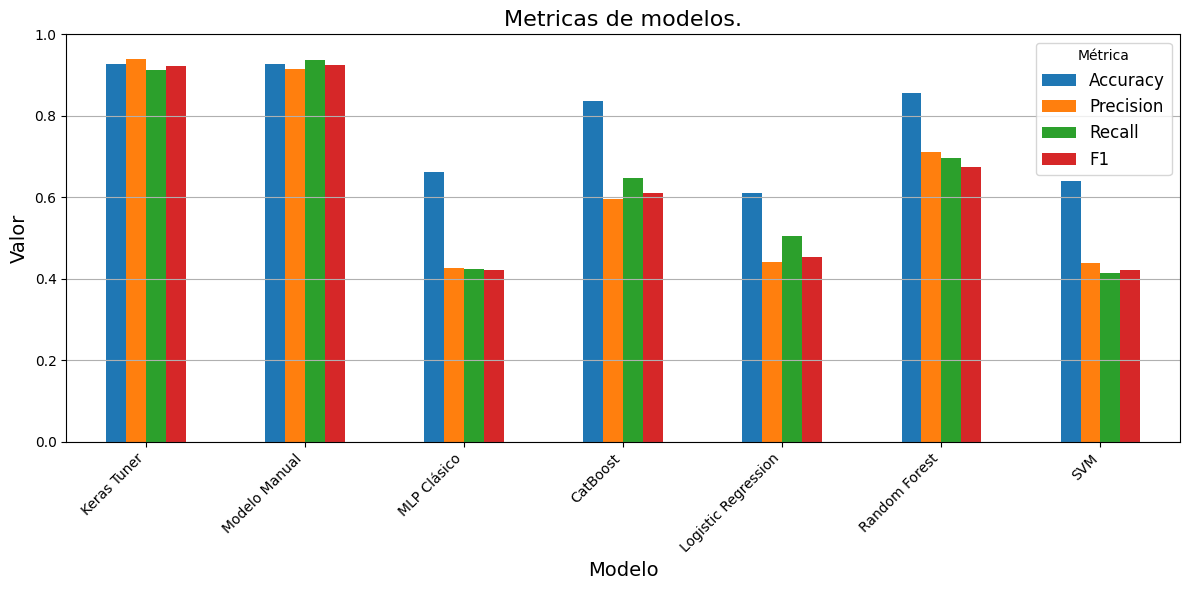

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))
comparacion_modelos.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar", ax=ax)
plt.title("Metricas de modelos.", fontsize=16)
plt.ylabel("Valor", fontsize=14)
plt.ylim(0, 1)
plt.xlabel("Modelo", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.legend(title="Métrica", fontsize=12)
plt.tight_layout()
plt.show()

## grafico de ganancia

In [47]:
y_prob_best = best_model.predict([X_test[col] for col in X_test.columns])
y_prob_manual = modelo_manual.predict([X_test[col] for col in X_test.columns])
y_prob_mlp = modelo_mlp.predict(X_test_mlp)
y_prob_cat = modelo_cat.predict_proba(X_test_cat)
y_prob_lr = modelo_lr.predict_proba(X_test_sklearn)
y_prob_rf = modelo_rf.predict_proba(X_test_sklearn)
y_prob_svm = modelo_svm.predict_proba(X_test_sklearn)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [48]:
print(y_prob_mlp.shape)

(443,)


In [49]:
y_prob_cat = y_prob_cat[:, 1]
y_prob_lr = y_prob_lr[:, 1]
y_prob_rf = y_prob_rf[:, 1]
y_prob_svm = y_prob_svm[:, 1]

In [50]:
modelos_probs = {
    "mejor_modelo.keras": y_prob_best,
    "mejor_modelo_manual": y_prob_manual,
    "MLP Clásico": y_prob_mlp,
    "CatBoost": y_prob_cat,
    "Logistic Regression": y_prob_lr,
    "Random Forest": y_prob_rf,
    "SVM": y_prob_svm
}
y_test_dict = {
    "mejor_modelo.keras": y_test_encoded,
    "mejor_modelo_manual": y_test_encoded,
    "MLP Clásico": y_test_encoded,
    "CatBoost": y_test_encoded,
    "Logistic Regression": y_test_encoded,
    "Random Forest": y_test_encoded,
    "SVM": y_test_encoded
}

In [51]:
# Función para graficar curva de ganancia
def plot_gain_curve(y_true, y_probs, label, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    sorted_indices = np.argsort(y_probs)[::-1]
    y_true_sorted = np.array(y_true)[sorted_indices]
    cum_gain = np.cumsum(y_true_sorted)
    total_positives = np.sum(y_true_sorted)
    pct_samples = np.arange(1, len(y_true_sorted)+1) / len(y_true_sorted)
    gain = cum_gain / total_positives
    ax.plot(pct_samples, gain, label=label)
    ax.set_xlabel('Porcentaje de muestras (ordenadas por score)', fontsize=12)
    ax.set_ylabel('Ganancia acumulada', fontsize=12)
    ax.set_title('Curva de Ganancia de Modelos', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    return ax

## mejor modelo

como esta keras tuner

In [52]:
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model

In [54]:
# Cargar modelo obtenido
modelo_best = load_model("mejor_modelo_manual.keras")

In [55]:
y_score_best = modelo_best.predict([X_test[col] for col in X_test.columns])
y_pred_best = np.argmax(y_score_best, axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


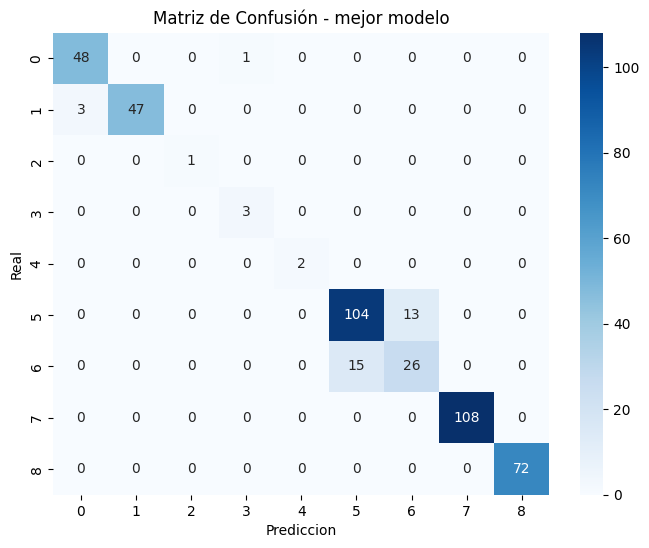

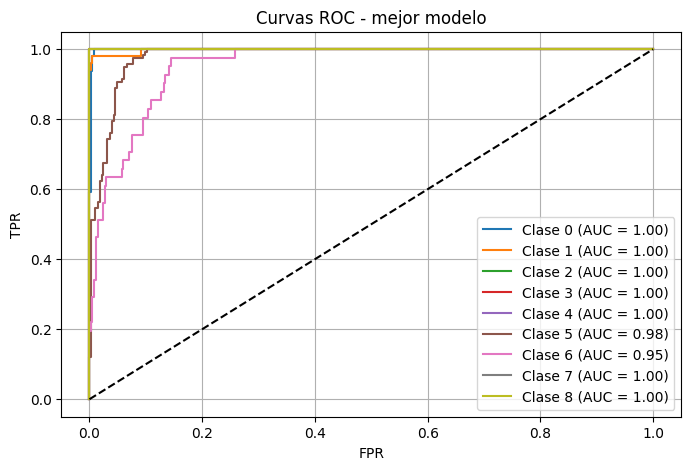

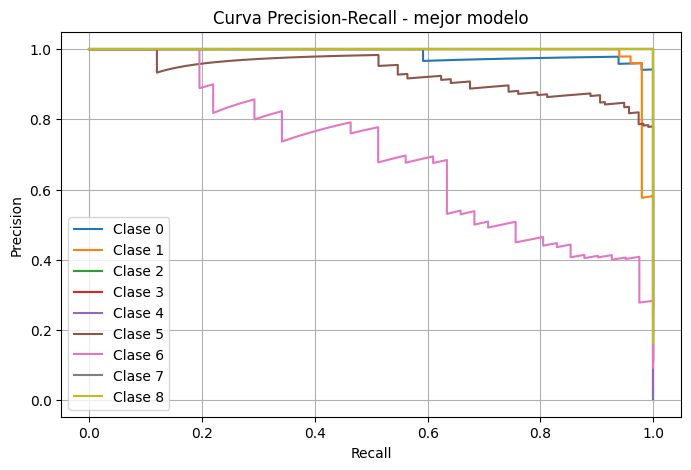

In [56]:
# Matriz
cm = confusion_matrix(y_test_encoded, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - mejor modelo")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.show()

# Curva ROC
y_test_bin = label_binarize(y_test_encoded, classes=np.unique(y_test_encoded))
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_best[:, i])
    roc_auc[i] = roc_auc_score(y_test_bin[:, i], y_score_best[:, i])

plt.figure(figsize=(8, 5))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Clase {i} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curvas ROC - mejor modelo")
plt.legend()
plt.grid(True)
plt.show()
# Curva Precision-Recall
plt.figure(figsize=(8, 5))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_best[:, i])
    plt.plot(recall, precision, label=f"Clase {i}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - mejor modelo")
plt.legend()
plt.grid(True)
plt.show()

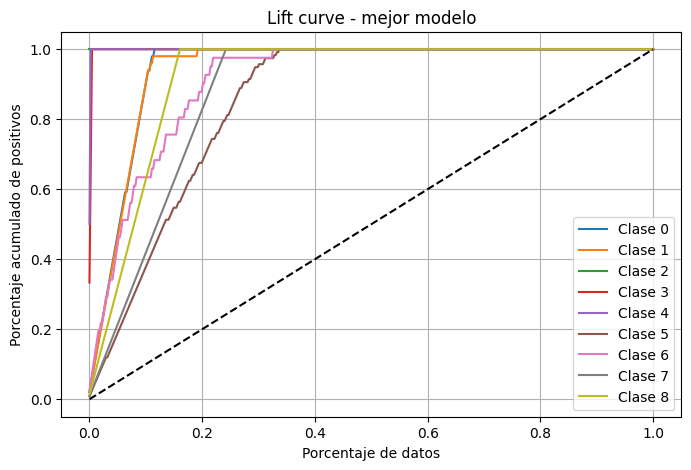

In [57]:
# Curva de Ganancia (Lift Curve)
plt.figure(figsize=(8,5))
for i in range(n_classes):
    sorted_indices = np.argsort(-y_score_best[:, i])
    cum_gain = np.cumsum(y_test_bin[sorted_indices, i])
    cum_gain = cum_gain / cum_gain[-1]
    plt.plot(np.linspace(0, 1, len(cum_gain)), cum_gain, label=f"Clase {i}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("Porcentaje de datos")
plt.ylabel("Porcentaje acumulado de positivos")
plt.title("Lift curve - mejor modelo")
plt.legend()
plt.grid(True)
plt.show()

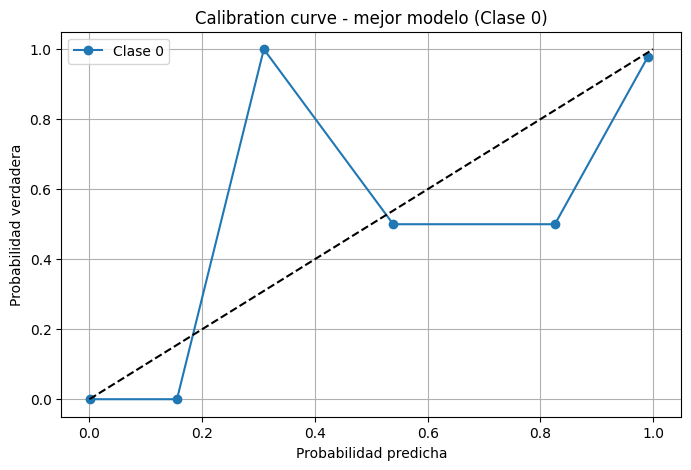

In [ ]:
# Calibration Curve (clase 0)
plt.figure(figsize=(8, 5))
prob_true, prob_pred = calibration_curve(y_test_bin[:, 0], y_score_best[:, 0], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Clase 0')
plt.plot([0,1], [0,1], linestyle='--', color='k')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad verdadera")
plt.title("Calibration curve - mejor modelo (Clase 0)")
plt.legend()
plt.grid(True)
plt.show()

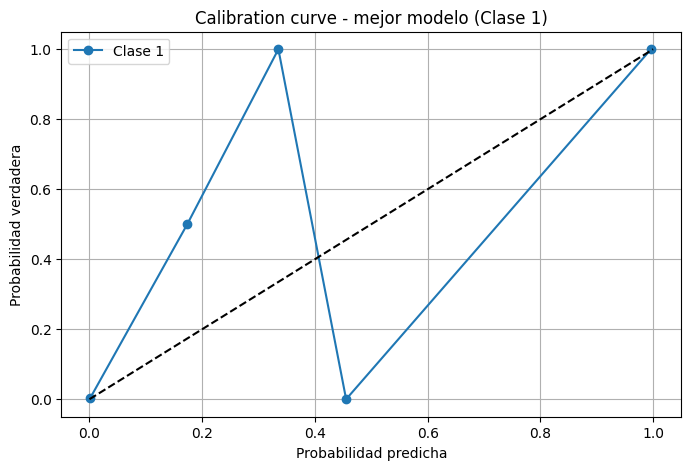

In [ ]:
# Calibration Curve (clase 1)
plt.figure(figsize=(8, 5))
prob_true, prob_pred = calibration_curve(y_test_bin[:, 1], y_score_best[:, 1], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Clase 1')
plt.plot([0,1], [0,1], linestyle='--', color='k')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad verdadera")
plt.title("Calibration curve - mejor modelo (Clase 1)")
plt.legend()
plt.grid(True)
plt.show()

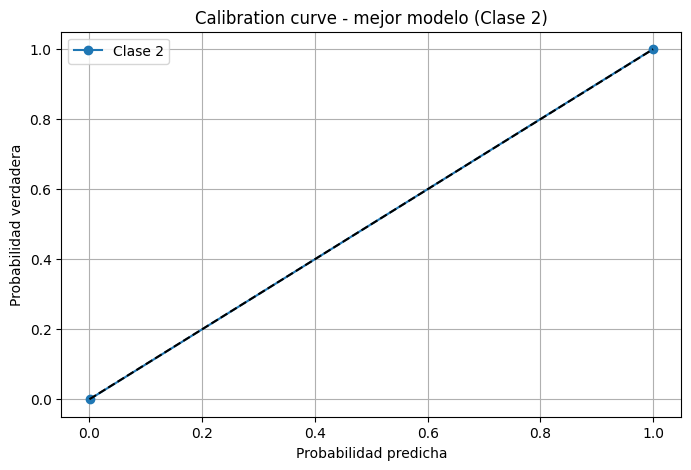

In [86]:
# Calibration Curve (clase 2)
plt.figure(figsize=(8, 5))
prob_true, prob_pred = calibration_curve(y_test_bin[:, 2], y_score_best[:, 2], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Clase 2')
plt.plot([0,1], [0,1], linestyle='--', color='k')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad verdadera")
plt.title("Calibration curve - mejor modelo (Clase 2)")
plt.legend()
plt.grid(True)
plt.show()

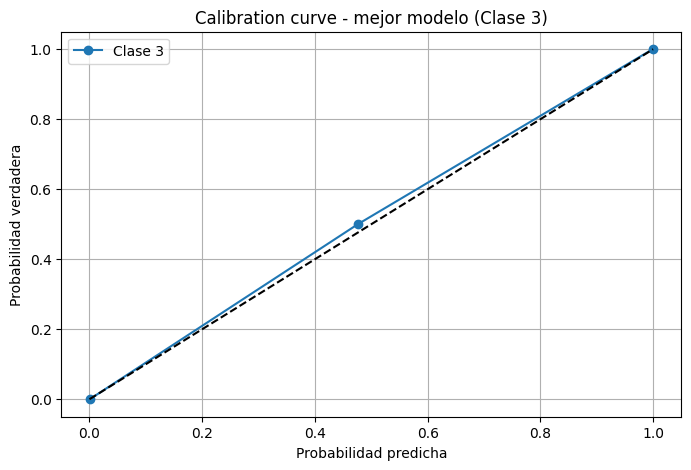

In [87]:
# Calibration Curve (clase 3)
plt.figure(figsize=(8, 5))
prob_true, prob_pred = calibration_curve(y_test_bin[:, 3], y_score_best[:, 3], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Clase 3')
plt.plot([0,1], [0,1], linestyle='--', color='k')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad verdadera")
plt.title("Calibration curve - mejor modelo (Clase 3)")
plt.legend()
plt.grid(True)
plt.show()

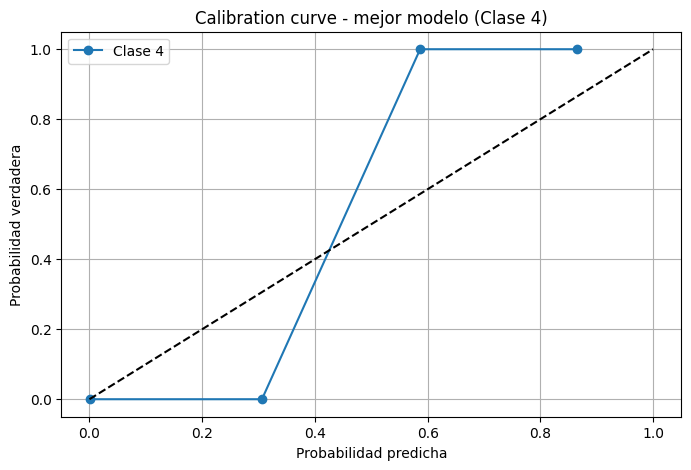

In [88]:
# Calibration Curve (clase 4)
plt.figure(figsize=(8, 5))
prob_true, prob_pred = calibration_curve(y_test_bin[:, 4], y_score_best[:, 4], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Clase 4')
plt.plot([0,1], [0,1], linestyle='--', color='k')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad verdadera")
plt.title("Calibration curve - mejor modelo (Clase 4)")
plt.legend()
plt.grid(True)
plt.show()

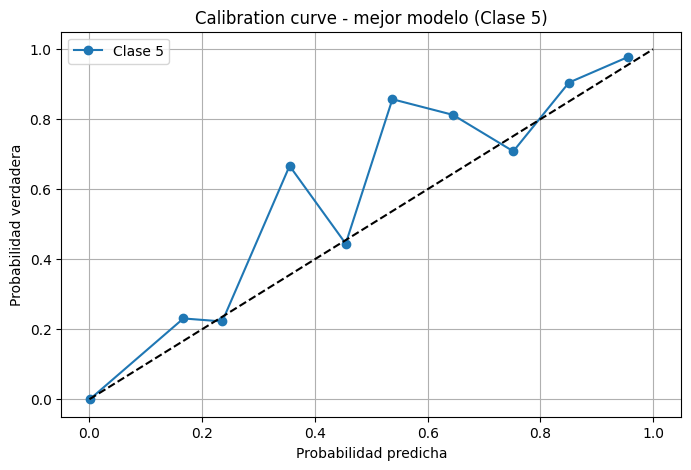

In [89]:
# Calibration Curve (clase 5)
plt.figure(figsize=(8, 5))
prob_true, prob_pred = calibration_curve(y_test_bin[:, 5], y_score_best[:, 5], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Clase 5')
plt.plot([0,1], [0,1], linestyle='--', color='k')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad verdadera")
plt.title("Calibration curve - mejor modelo (Clase 5)")
plt.legend()
plt.grid(True)
plt.show()

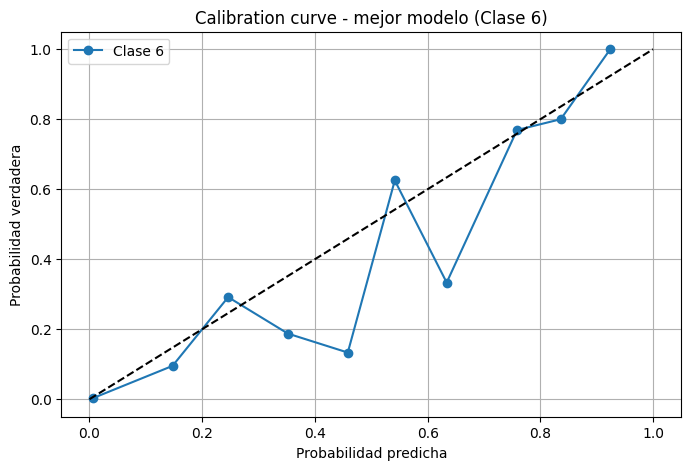

In [90]:
# Calibration Curve (clase 6)
plt.figure(figsize=(8, 5))
prob_true, prob_pred = calibration_curve(y_test_bin[:, 6], y_score_best[:, 6], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Clase 6')
plt.plot([0,1], [0,1], linestyle='--', color='k')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad verdadera")
plt.title("Calibration curve - mejor modelo (Clase 6)")
plt.legend()
plt.grid(True)
plt.show()

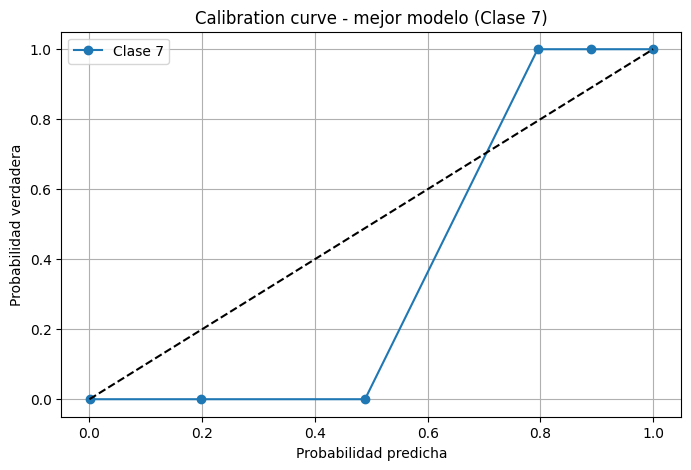

In [91]:
# Calibration Curve (clase 7)
plt.figure(figsize=(8, 5))
prob_true, prob_pred = calibration_curve(y_test_bin[:, 7], y_score_best[:, 7], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Clase 7')
plt.plot([0,1], [0,1], linestyle='--', color='k')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad verdadera")
plt.title("Calibration curve - mejor modelo (Clase 7)")
plt.legend()
plt.grid(True)
plt.show()

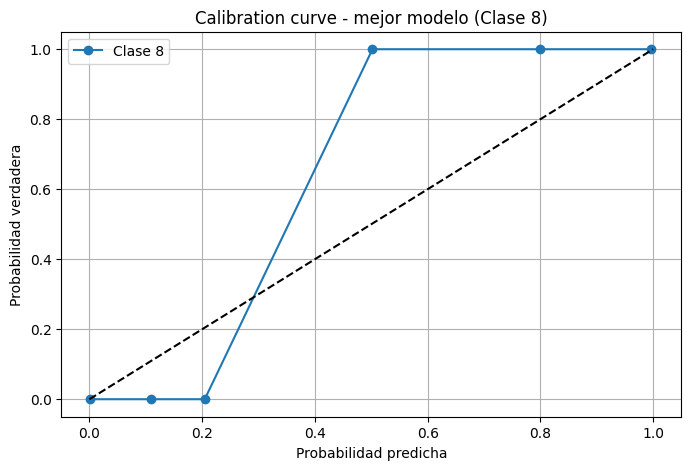

In [92]:
# Calibration Curve (clase 8)
plt.figure(figsize=(8, 5))
prob_true, prob_pred = calibration_curve(y_test_bin[:, 8], y_score_best[:, 8], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Clase 8')
plt.plot([0,1], [0,1], linestyle='--', color='k')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad verdadera")
plt.title("Calibration curve - mejor modelo (Clase 8)")
plt.legend()
plt.grid(True)
plt.show()

In [95]:
print(y_score_best.shape)
print(y_test_bin.shape)

(443, 9)
(443, 9)


In [59]:
print(le_grd.classes_)

[ 41023  44153  61131  71141 134161 146101 146102 146121 146131]


In [60]:
df["GRD"].value_counts().nlargest(10).index.tolist()

[146101, 146121, 146131, 158171, 134161, 71141, 44153, 61131, 41023, 146102]

metricas predecir 3 grd

In [62]:
# Prediccion primerso 10 GRD's
y_score_best = modelo_best.predict([X_test[col] for col in X_test.columns])
y_pred_best = np.argmax(y_score_best, axis=1)
y_test_real = le_grd.inverse_transform(y_test_encoded)
y_pred_real = le_grd.inverse_transform(y_pred_best)
# Dataframe
df_comparacion = pd.DataFrame({"GRD_Real": y_test_real,"GRD_Predicho": y_pred_real})
# Mostrar
print(df_comparacion.head(10))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
   GRD_Real  GRD_Predicho
0    146101        146101
1    146101        146101
2    146101        146101
3     71141         71141
4    146101        146102
5    146121        146121
6    146102        146102
7     41023         41023
8    146121        146121
9     41023         41023


## predecir individual

predecir 1 grd 146101

In [63]:
# Prediccion GRD=146101
y_score_best = modelo_best.predict([X_test[col] for col in X_test.columns])
y_pred_best = np.argmax(y_score_best, axis=1)
y_test_real = le_grd.inverse_transform(y_test_encoded)
y_pred_real = le_grd.inverse_transform(y_pred_best)
# Dataframe
df_comparacion = pd.DataFrame({
    "GRD_Real": y_test_real,
    "GRD_Predicho": y_pred_real
})
df_comparacion["GRD_Real"] = df_comparacion["GRD_Real"].astype(str)
df_comparacion["GRD_Predicho"] = df_comparacion["GRD_Predicho"].astype(str)
df_comparacion_filtrado = df_comparacion[df_comparacion["GRD_Real"] == "146101"] # GRD=146101
# Mostrar las primeras 10 filas
print("\nComparacion de GRD reales 146101:")
print(df_comparacion_filtrado.head(10))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Comparacion de GRD reales 146101:
   GRD_Real GRD_Predicho
0    146101       146101
1    146101       146101
2    146101       146101
4    146101       146102
13   146101       146101
15   146101       146101
18   146101       146101
20   146101       146101
21   146101       146101
34   146101       146101


146102

In [64]:
# Prediccion GRD=146102
y_score_best = modelo_best.predict([X_test[col] for col in X_test.columns])
y_pred_best = np.argmax(y_score_best, axis=1)
y_test_real = le_grd.inverse_transform(y_test_encoded)
y_pred_real = le_grd.inverse_transform(y_pred_best)
# Dataframe
df_comparacion = pd.DataFrame({
    "GRD_Real": y_test_real,
    "GRD_Predicho": y_pred_real
})
df_comparacion["GRD_Real"] = df_comparacion["GRD_Real"].astype(str)
df_comparacion["GRD_Predicho"] = df_comparacion["GRD_Predicho"].astype(str)
df_comparacion_filtrado = df_comparacion[df_comparacion["GRD_Real"] == "146102"] # GRD=146102
# Mostrar las primeras 10 filas
print("\nComparacion de GRD reales 146102:")
print(df_comparacion_filtrado.head(10))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Comparacion de GRD reales 146102:
   GRD_Real GRD_Predicho
6    146102       146102
12   146102       146101
16   146102       146101
22   146102       146102
24   146102       146102
26   146102       146102
28   146102       146101
33   146102       146101
45   146102       146102
48   146102       146102


44153

In [65]:
# Prediccion GRD=44153
y_score_best = modelo_best.predict([X_test[col] for col in X_test.columns])
y_pred_best = np.argmax(y_score_best, axis=1)
y_test_real = le_grd.inverse_transform(y_test_encoded)
y_pred_real = le_grd.inverse_transform(y_pred_best)
# Dataframe
df_comparacion = pd.DataFrame({
    "GRD_Real": y_test_real,
    "GRD_Predicho": y_pred_real
})
df_comparacion["GRD_Real"] = df_comparacion["GRD_Real"].astype(str)
df_comparacion["GRD_Predicho"] = df_comparacion["GRD_Predicho"].astype(str)
df_comparacion_filtrado = df_comparacion[df_comparacion["GRD_Real"] == "44153"] # GRD=44153
# Mostrar las primeras 10 filas
print("\nComparacion de GRD reales 44153:")
print(df_comparacion_filtrado.head(10))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Comparacion de GRD reales 44153:
    GRD_Real GRD_Predicho
25     44153        44153
40     44153        44153
41     44153        44153
43     44153        44153
49     44153        41023
69     44153        44153
74     44153        44153
78     44153        44153
101    44153        44153
104    44153        44153


# graficos con shap

In [66]:
import shap

e:\multimedia\coding\python\codigoF - S1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
modelo_manual = load_model("mejor_modelo_manual.keras")

In [ ]:
print("X_kernel shape:", X_kernel.shape)
print("SHAP values shape:", np.array(shap_values[0]).shape)

X_kernel shape: (100, 19)
SHAP values shape: (19, 9)


In [ ]:
def predict_class0(X_array):
    X_input = [X_array[:, i] for i in range(X_array.shape[1])]
    return modelo_manual.predict(X_input)[:, 0]  # Solo clase 0
X_sample_input = [X_test[col].to_numpy() for col in X_test.columns]
X_kernel = np.column_stack(X_sample_input)

In [ ]:
explainer = shap.KernelExplainer(predict_class0, X_kernel)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


Using 443 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


In [ ]:
shap_values = explainer.shap_values(X_kernel, nsamples=100)

  0%|          | 0/443 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


  0%|          | 1/443 [00:02<16:37,  2.26s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


  0%|          | 2/443 [00:04<16:25,  2.23s/it]

...

100%|█████████▉| 441/443 [16:00<00:04,  2.22s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


100%|█████████▉| 442/443 [16:02<00:02,  2.24s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


100%|██████████| 443/443 [16:04<00:00,  2.18s/it]


C:\Users\mgodo\AppData\Local\Temp\ipykernel_11664\2168145797.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_kernel, feature_names=X_test.columns)


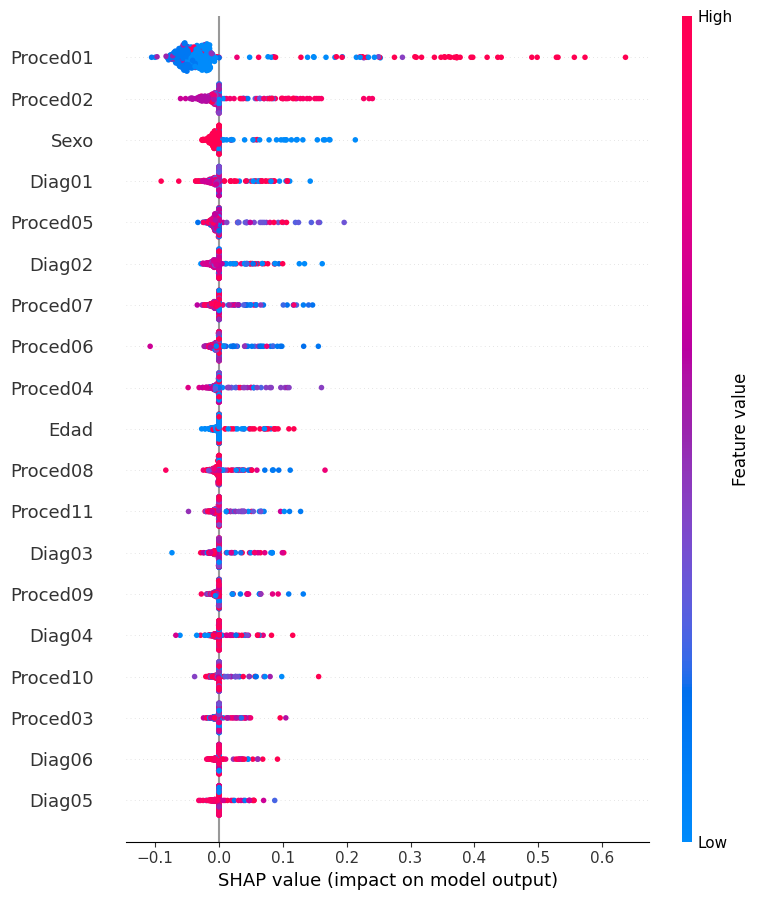

In [85]:
# 5. Ahora visualizar correctamente
shap.summary_plot(shap_values, X_kernel, feature_names=X_test.columns)

In [ ]:
print("X_kernel shape:", X_kernel.shape)
print("SHAP values shape:", np.array(shap_values[1]).shape)

X_kernel shape: (443, 19)
SHAP values shape: (19,)


In [ ]:
def predict_class0(X_array):
    X_input = [X_array[:, i] for i in range(X_array.shape[1])]
    return modelo_manual.predict(X_input)[:, 1]  # Solo clase 0
X_sample_input = [X_test[col].to_numpy() for col in X_test.columns]
X_kernel = np.column_stack(X_sample_input)

In [ ]:
explainer = shap.KernelExplainer(predict_class0, X_kernel)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


Using 443 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


In [ ]:
shap_values = explainer.shap_values(X_kernel, nsamples=100)

  0%|          | 0/443 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


  0%|          | 1/443 [00:02<15:55,  2.16s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


  0%|          | 2/443 [00:04<16:02,  2.18s/it]

...

100%|█████████▉| 441/443 [16:12<00:04,  2.23s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


100%|█████████▉| 442/443 [16:14<00:02,  2.25s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


100%|██████████| 443/443 [16:16<00:00,  2.21s/it]


C:\Users\mgodo\AppData\Local\Temp\ipykernel_11664\2168145797.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_kernel, feature_names=X_test.columns)


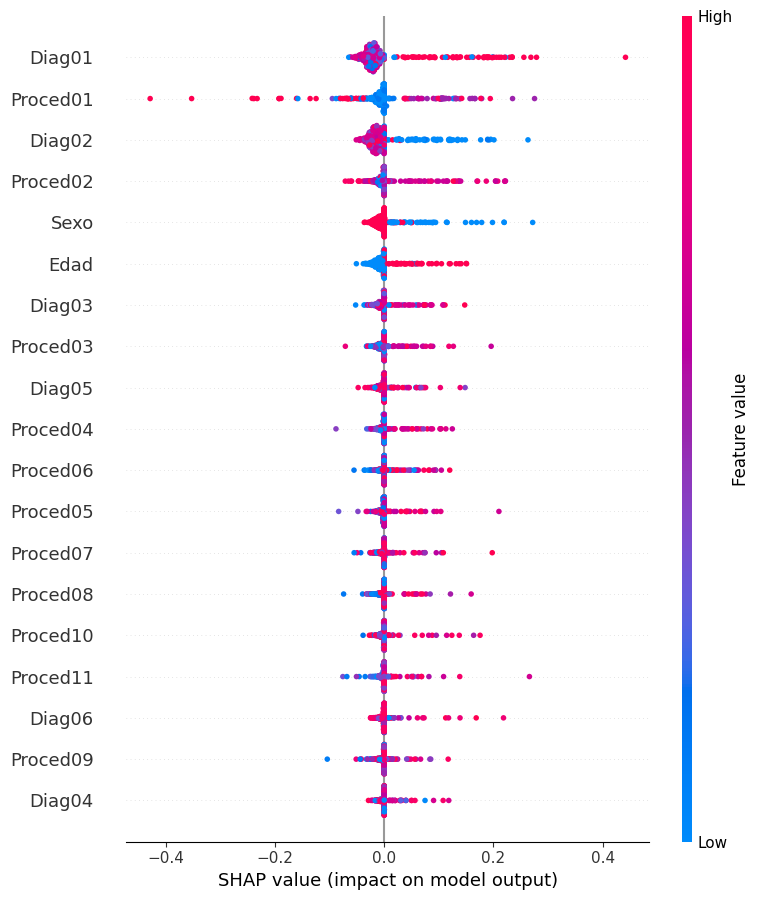

In [ ]:
shap.summary_plot(shap_values, X_kernel, feature_names=X_test.columns)